## Ejercicio 1

Implemente las estructuras de datos y algoritmos básicos para la solución de un problema mediante algoritmos genéticos. Pruebe estas rutinas y compare los resultados con un método de gradiente descendiente para buscar el mínimo global de las siguientes funciones:

### Idea del algoritmo evolutivo

```mermaid
flowchart TD
    A["Población inicial: individuos con bits al azar"] --> B["Decodificar cada individuo a (x) o (x, y) y evaluar aptitud = −f"]
    B --> C{"¿Se alcanzó el máximo de generaciones?"}
    C -- Sí --> Z(["Fin: mejor individuo"])
    C -- No --> E["Elitismo: el mejor pasa directo a la nueva población"]
    E --> D["Selección por torneo: padre y madre"]
    D --> F["Cruce en un punto → 2 hijos"]
    F --> G["Mutación: cada bit cambia con prob. 1/n_bits"]
    G --> I{"¿Nueva población completa?"}
    I -- No --> D
    I -- Sí --> B
```

- El código está separado en dos partes: `AlgoritmoGenetico` es el motor (selección, cruce, mutación, elitismo) y no sabe qué problema resuelve; cada problema es una clase hija que define `decodificar` y `aptitud`. En este ejercicio es `MinimizarFuncion`; en el ejercicio 2 se reutiliza el mismo motor.
- Cada **individuo** es una lista de bits. Para evaluarlo se **decodifica**: cada grupo de bits se pasa a entero y ese entero se lleva al intervalo de la variable.
- Como el algoritmo busca la **mayor** aptitud y nosotros el **mínimo** de $f$, la aptitud es $-f$.

| | Inciso 1 | Inciso 2 |
|---|---|---|
| Individuo | 20 bits → $x \in [-512, 512]$ | 20 + 20 bits → $(x, y) \in [-100, 100]^2$ |
| Resolución | $1024 / (2^{20}-1) \approx 0.001$ | $200 / (2^{20}-1) \approx 0.0002$ |
| Mínimo global | $f(420.97) \approx -418.98$ | $f(0, 0) = 0$ |

In [1]:
import math
import random
import csv
import pandas as pd
import matplotlib.pyplot as plt


#motor genérico del algoritmo genético: no sabe qué problema resuelve.
#cada problema es una clase hija que define decodificar() y aptitud()
class AlgoritmoGenetico:

    def __init__(self, n_bits, tam_poblacion=50, prob_cruce=0.9, prob_mutacion=None,
                 tam_torneo=3, max_generaciones=200, semilla=None):
        self.n_bits = n_bits
        self.tam_poblacion = tam_poblacion
        self.prob_cruce = prob_cruce
        if prob_mutacion is None:
            prob_mutacion = 1 / n_bits              # en promedio cambia 1 bit por hijo
        self.prob_mutacion = prob_mutacion
        self.tam_torneo = tam_torneo
        self.max_generaciones = max_generaciones
        random.seed(semilla)                        # misma semilla = mismos resultados

    #un individuo es una lista de bits al azar, por ejemplo [1, 0, 0, 1, ...]
    def crear_individuo(self):
        individuo = []
        for i in range(self.n_bits):
            individuo.append(random.randint(0, 1))
        return individuo

    #estas dos dependen del problema, las define cada clase hija
    def decodificar(self, individuo):
        raise NotImplementedError

    def aptitud(self, individuo):
        raise NotImplementedError

    #torneo: elijo tam_torneo individuos al azar y gana el de mayor aptitud
    def seleccion(self, poblacion, aptitudes):
        ganador = random.randrange(len(poblacion))
        for i in range(self.tam_torneo - 1):
            rival = random.randrange(len(poblacion))
            if aptitudes[rival] > aptitudes[ganador]:
                ganador = rival
        return poblacion[ganador]

    #cruce en un punto: corto a los dos padres en el mismo lugar e intercambio las partes
    def cruce(self, padre, madre):
        if random.random() < self.prob_cruce:
            corte = random.randint(1, self.n_bits - 1)
            hijo1 = padre[:corte] + madre[corte:]
            hijo2 = madre[:corte] + padre[corte:]
        else:
            hijo1 = padre[:]
            hijo2 = madre[:]
        return hijo1, hijo2

    #cada bit cambia (0 -> 1 o 1 -> 0) con probabilidad prob_mutacion
    def mutacion(self, individuo):
        mutado = []
        for bit in individuo:
            if random.random() < self.prob_mutacion:
                mutado.append(1 - bit)
            else:
                mutado.append(bit)
        return mutado

    def indice_del_mejor(self, aptitudes):
        mejor = 0
        for i in range(len(aptitudes)):
            if aptitudes[i] > aptitudes[mejor]:
                mejor = i
        return mejor

    def ejecutar(self):
        poblacion = []
        for i in range(self.tam_poblacion):
            poblacion.append(self.crear_individuo())

        #guardo información de cada generación para graficar después
        self.historial = []             # todos los individuos decodificados
        self.mejores = []               # el mejor individuo decodificado
        self.mejores_aptitudes = []     # la aptitud del mejor

        for generacion in range(self.max_generaciones):
            #evalúo a toda la población
            aptitudes = []
            decodificados = []
            for individuo in poblacion:
                aptitudes.append(self.aptitud(individuo))
                decodificados.append(self.decodificar(individuo))

            mejor = self.indice_del_mejor(aptitudes)
            self.historial.append(decodificados)
            self.mejores.append(decodificados[mejor])
            self.mejores_aptitudes.append(aptitudes[mejor])

            #elitismo: el mejor pasa directo a la nueva población
            nueva_poblacion = [poblacion[mejor]]

            #el resto de la nueva población son hijos
            while len(nueva_poblacion) < self.tam_poblacion:
                padre = self.seleccion(poblacion, aptitudes)
                madre = self.seleccion(poblacion, aptitudes)
                hijo1, hijo2 = self.cruce(padre, madre)
                nueva_poblacion.append(self.mutacion(hijo1))
                if len(nueva_poblacion) < self.tam_poblacion:
                    nueva_poblacion.append(self.mutacion(hijo2))

            poblacion = nueva_poblacion

        #devuelvo el mejor individuo de la última generación (decodificado) y su aptitud
        aptitudes = []
        for individuo in poblacion:
            aptitudes.append(self.aptitud(individuo))
        mejor = self.indice_del_mejor(aptitudes)
        return self.decodificar(poblacion[mejor]), aptitudes[mejor]

In [2]:
#problema del ejercicio 1: minimizar una función de una o dos variables reales
class MinimizarFuncion(AlgoritmoGenetico):

    def __init__(self, funcion, limites, bits_por_variable, tam_poblacion=50,
                 max_generaciones=200, semilla=None):
        self.funcion = funcion                      # función a minimizar, recibe una lista: [x] o [x, y]
        self.limites = limites                      # [(min, max)] por cada variable
        self.bits_por_variable = bits_por_variable
        n_bits = bits_por_variable * len(limites)
        AlgoritmoGenetico.__init__(self, n_bits, tam_poblacion=tam_poblacion,
                                   max_generaciones=max_generaciones, semilla=semilla)

    #paso una lista de bits a entero, por ejemplo [1, 0, 1] -> 5
    def binario_a_entero(self, bits):
        entero = 0
        for bit in bits:
            entero = entero * 2 + bit
        return entero

    #paso el individuo (bits) al punto que representa: [x] o [x, y]
    def decodificar(self, individuo):
        punto = []
        maximo_entero = 2 ** self.bits_por_variable - 1
        for i in range(len(self.limites)):
            inicio = i * self.bits_por_variable
            fin = inicio + self.bits_por_variable
            entero = self.binario_a_entero(individuo[inicio:fin])

            #llevo el entero de [0, maximo_entero] al intervalo [a, b] de la variable
            a, b = self.limites[i]
            valor = a + entero * (b - a) / maximo_entero
            punto.append(valor)
        return punto

    #como buscamos el mínimo de f, mayor aptitud = menor f
    def aptitud(self, individuo):
        return -self.funcion(self.decodificar(individuo))

### Gradiente descendiente

En cada paso se calcula el gradiente de $f$ y se avanza en sentido contrario: $\;p \leftarrow p - \eta \, \nabla f(p)$.
El gradiente se aproxima numéricamente con diferencias centradas: $\;\dfrac{\partial f}{\partial x_i} \approx \dfrac{f(p + h\,e_i) - f(p - h\,e_i)}{2h}$.

In [3]:
def gradiente_descendiente(funcion, punto_inicial, limites, tasa=0.1, iteraciones=1000, h=1e-6):
    punto = punto_inicial[:]
    trayectoria = [punto[:]]     # guardo el camino para graficarlo

    for it in range(iteraciones):
        #derivada parcial de cada variable por diferencias centradas
        gradiente = []
        for i in range(len(punto)):
            adelante = punto[:]
            atras = punto[:]
            adelante[i] = adelante[i] + h
            atras[i] = atras[i] - h
            gradiente.append((funcion(adelante) - funcion(atras)) / (2 * h))

        #doy un paso en contra del gradiente, sin salirme de los límites
        for i in range(len(punto)):
            punto[i] = punto[i] - tasa * gradiente[i]
            minimo, maximo = limites[i]
            if punto[i] < minimo:
                punto[i] = minimo
            if punto[i] > maximo:
                punto[i] = maximo

        trayectoria.append(punto[:])

    return punto, funcion(punto), trayectoria

### Comparación y gráficos

In [4]:
#tabla con el mejor f, el f promedio y cuántas corridas llegaron al mínimo global
def comparar(resultados_ag, resultados_gd, f_optimo, tolerancia=0.1):
    filas = []
    for resultados in [resultados_ag, resultados_gd]:
        valores = []
        for resultado in resultados:
            valores.append(resultado[1])        # resultado = (punto, f(punto), ...)

        llegaron = 0
        for valor in valores:
            if valor - f_optimo < tolerancia:
                llegaron = llegaron + 1

        filas.append([min(valores), sum(valores) / len(valores), f"{llegaron}/{len(valores)}"])

    return pd.DataFrame(filas, columns=["mejor f", "f promedio", "llegó al mínimo global"],
                        index=["Algoritmo genético", "Gradiente descendiente"])


AZUL = "#2a78d6"     # algoritmo genético
NARANJA = "#eb6834"  # gradiente descendiente
GRIS = "#8a8a8a"     # función


#dibuja la función de fondo: una curva si es f(x), un mapa de colores si es f(x, y)
def dibujar_funcion(ax, funcion, limites, barra=True):
    if len(limites) == 1:
        a, b = limites[0]
        xs = []
        ys = []
        for i in range(1000):
            x = a + i * (b - a) / 999
            xs.append(x)
            ys.append(funcion([x]))
        ax.plot(xs, ys, color=GRIS)
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
    else:
        x_min, x_max = limites[0]
        y_min, y_max = limites[1]
        n = 300
        matriz = []     # matriz[i][j] = f(x_j, y_i)
        for i in range(n):
            y = y_min + i * (y_max - y_min) / (n - 1)
            fila = []
            for j in range(n):
                x = x_min + j * (x_max - x_min) / (n - 1)
                fila.append(funcion([x, y]))
            matriz.append(fila)
        mapa = ax.imshow(matriz, extent=[x_min, x_max, y_min, y_max], origin="lower", cmap="Greys")
        if barra:
            plt.colorbar(mapa, ax=ax, label="f(x, y)", shrink=0.8)
        ax.set_xlabel("x")
        ax.set_ylabel("y")


#dónde termina cada método: el gradiente va del punto hueco al lleno, el AG es la estrella
def graficar_comparacion(funcion, limites, resultados_ag, resultados_gd):
    if len(limites) == 1:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig, ax = plt.subplots(figsize=(7, 6))
    dibujar_funcion(ax, funcion, limites)

    for punto, valor, trayectoria in resultados_gd:
        inicio = trayectoria[0]
        fin = trayectoria[-1]
        if len(limites) == 1:
            #en 1D: flecha desde (x0, f(x0)) hasta (xf, f(xf))
            ax.annotate("", xy=(fin[0], funcion(fin)), xytext=(inicio[0], funcion(inicio)),
                        arrowprops=dict(arrowstyle="->", color=NARANJA, linewidth=1.5))
            ax.plot(inicio[0], funcion(inicio), "o", markerfacecolor="white", markeredgecolor=NARANJA, markersize=8)
            ax.plot(fin[0], funcion(fin), "o", color=NARANJA, markersize=8)
        else:
            #en 2D: el camino completo sobre el mapa
            xs = []
            ys = []
            for p in trayectoria:
                xs.append(p[0])
                ys.append(p[1])
            ax.plot(xs, ys, color=NARANJA, linewidth=1.5)
            ax.plot(inicio[0], inicio[1], "o", markerfacecolor="white", markeredgecolor=NARANJA, markersize=8)
            ax.plot(fin[0], fin[1], "o", color=NARANJA, markersize=8)

    for punto, valor in resultados_ag:
        if len(limites) == 1:
            ax.plot(punto[0], valor, "*", color=AZUL, markeredgecolor="white", markersize=16)
        else:
            ax.plot(punto[0], punto[1], "*", color=AZUL, markeredgecolor="white", markersize=16)

    #leyenda (un solo elemento por método)
    ax.plot([], [], "o", color=NARANJA, label="Gradiente descendiente")
    ax.plot([], [], "*", color=AZUL, markersize=12, label="Algoritmo genético")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
    ax.set_title("Dónde termina cada método (gradiente: inicio hueco → fin lleno)")
    plt.show()


#la población del AG sobre la función, en algunas generaciones
def graficar_evolucion(funcion, limites, historial, generaciones):
    fig, ejes = plt.subplots(1, len(generaciones), figsize=(4.5 * len(generaciones), 4))
    for k in range(len(generaciones)):
        g = generaciones[k]
        ax = ejes[k]
        es_la_ultima = (k == len(generaciones) - 1)
        dibujar_funcion(ax, funcion, limites, barra=es_la_ultima)

        for punto in historial[g]:
            if len(limites) == 1:
                ax.plot(punto[0], funcion(punto), "o", color=AZUL, markeredgecolor="white", markersize=8)
            else:
                ax.plot(punto[0], punto[1], "o", color=AZUL, markeredgecolor="white", markersize=8)
        ax.set_title(f"Generación {g}")

    fig.suptitle("Evolución de la población del algoritmo genético")
    plt.tight_layout()
    plt.show()

**Inciso 1**: $f(x) = -x \sin\left(\sqrt{|x|}\right), \quad -512 \leq x \leq 512$

Corro el algoritmo genético 10 veces (con semillas distintas) y el gradiente descendiente desde 10 puntos iniciales al azar.

In [5]:
def f1(punto):
    x = punto[0]
    return -x * math.sin(math.sqrt(abs(x)))

limites1 = [(-512, 512)]
corridas = 10

resultados_ag1 = []
for semilla in range(corridas):
    ag = MinimizarFuncion(f1, limites1, bits_por_variable=20, semilla=semilla)
    punto, aptitud = ag.ejecutar()
    resultados_ag1.append((punto, -aptitud))     # f = -aptitud

random.seed(0)
resultados_gd1 = []
for i in range(corridas):
    inicio = [random.uniform(-512, 512)]
    resultados_gd1.append(gradiente_descendiente(f1, inicio, limites1, tasa=1))

comparar(resultados_ag1, resultados_gd1, f_optimo=-418.98)

,mejor f,f promedio,llegó al mínimo global
Algoritmo genético,-418.982887,-418.982861,10/10
Gradiente descendiente,-418.982887,-158.350564,1/10


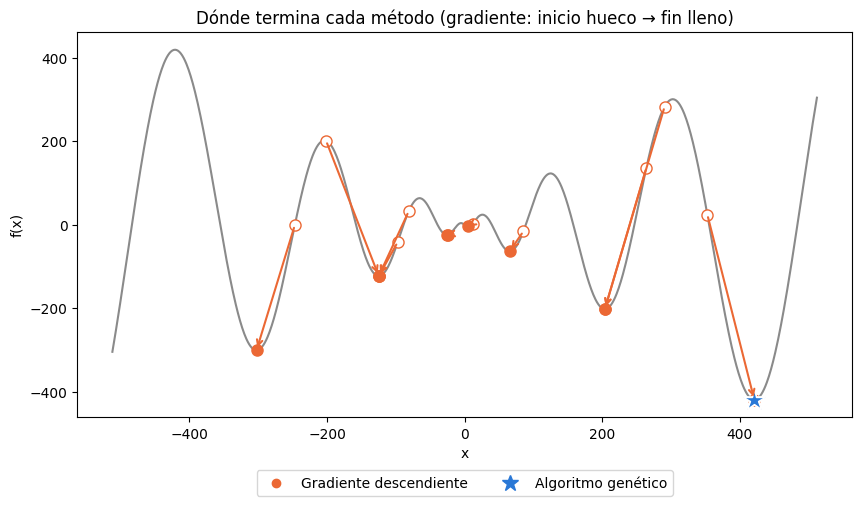

In [6]:
graficar_comparacion(f1, limites1, resultados_ag1, resultados_gd1)

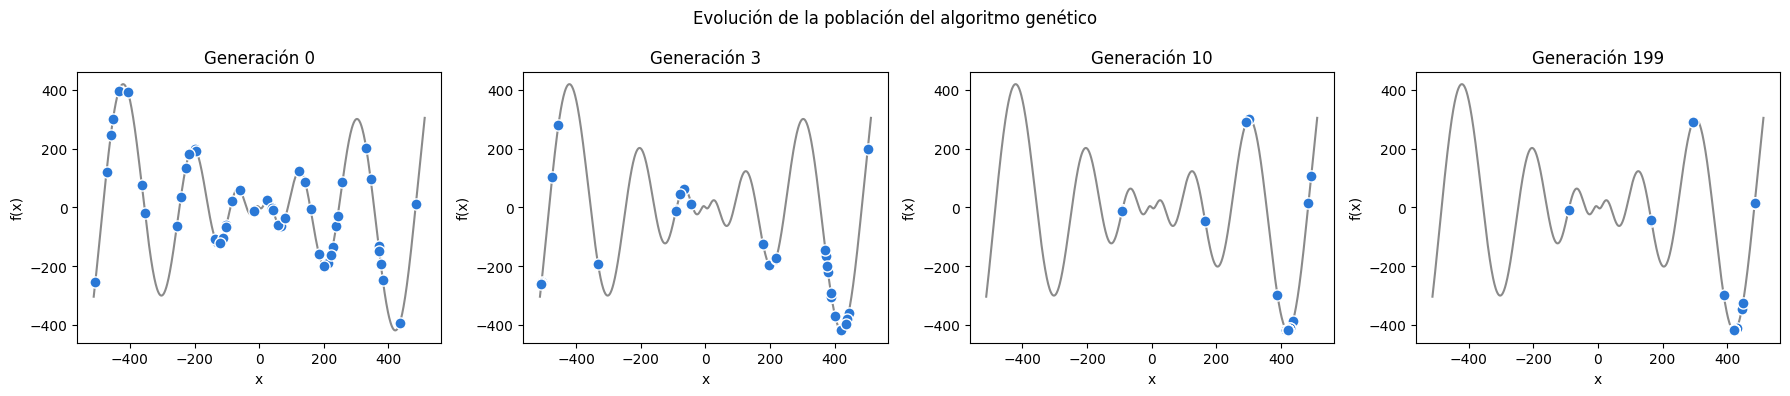

In [7]:
ag = MinimizarFuncion(f1, limites1, bits_por_variable=20, semilla=0)
ag.ejecutar()
graficar_evolucion(f1, limites1, ag.historial, generaciones=[0, 3, 10, 199])

**Inciso 2**: $f(x, y) = (x^2 + y^2)^{0.25} \left[\sin^2\left(50(x^2+y^2)^{0.1}\right) + 1\right], \quad -100 \leq x, y \leq 100$

In [8]:
def f2(punto):
    x = punto[0]
    y = punto[1]
    r2 = x**2 + y**2
    return r2**0.25 * (math.sin(50 * r2**0.1)**2 + 1)

limites2 = [(-100, 100), (-100, 100)]

resultados_ag2 = []
for semilla in range(corridas):
    ag = MinimizarFuncion(f2, limites2, bits_por_variable=20, semilla=semilla)
    punto, aptitud = ag.ejecutar()
    resultados_ag2.append((punto, -aptitud))     # f = -aptitud

random.seed(0)
resultados_gd2 = []
for i in range(corridas):
    inicio = [random.uniform(-100, 100), random.uniform(-100, 100)]
    resultados_gd2.append(gradiente_descendiente(f2, inicio, limites2, tasa=0.1))

comparar(resultados_ag2, resultados_gd2, f_optimo=0)

,mejor f,f promedio,llegó al mínimo global
Algoritmo genético,0.019960,0.019960,10/10
Gradiente descendiente,4.104469,7.893694,0/10


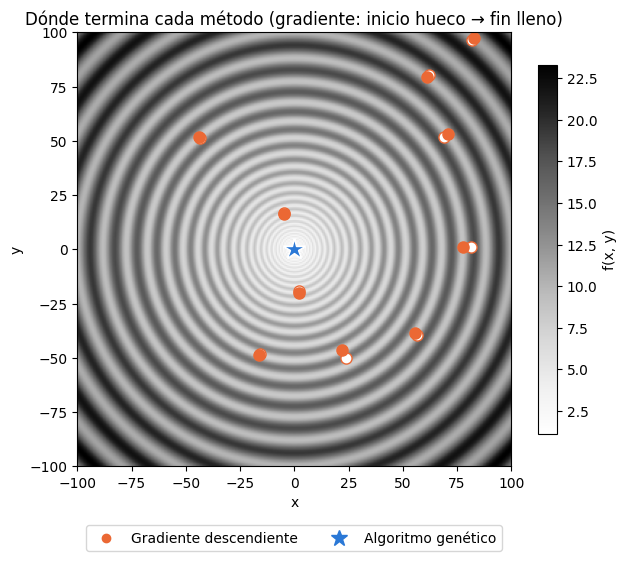

In [9]:
graficar_comparacion(f2, limites2, resultados_ag2, resultados_gd2)

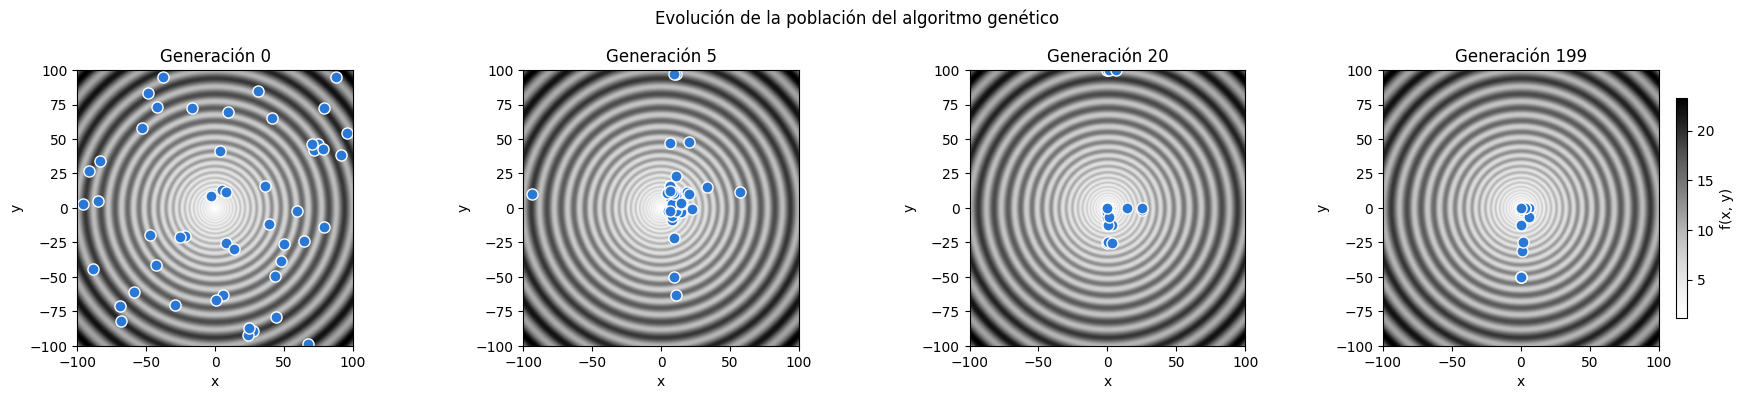

In [10]:
ag = MinimizarFuncion(f2, limites2, bits_por_variable=20, semilla=0)
ag.ejecutar()
graficar_evolucion(f2, limites2, ag.historial, generaciones=[0, 5, 20, 199])

### Conclusiones

- **El gradiente descendiente encuentra el mínimo más cercano al punto de partida.** En $f(x)$ llega al global solo cuando arranca en su valle; en $f(x, y)$, con mínimos locales en forma de anillos concéntricos, no llega nunca.
- **El algoritmo genético llega al mínimo global en todas las corridas**, porque la población explora todo el dominio a la vez y la selección la va concentrando en las mejores zonas.
- En el inciso 2 el AG no da exactamente $0$: con 20 bits por variable no existe un valor exactamente igual a $0$ (el más cercano es $\pm 0.0001$) y $f$ crece muy rápido cerca del origen. Con más bits ese valor baja.

## Ejercicio 2

Diseñe e implemente un algoritmo genético que busque el mejor subconjunto de características para la clasificación de cáncer (leucemia linfocítica aguda y leucemia mielógena aguda) a partir de datos genómicos. Se proveen 38 muestras en el conjunto de entrenamiento y 34 en el conjunto de prueba (`leukemia_train.csv` y `leukemia_test.csv`, respectivamente). Cada muestra se compone de un total de 7129 características, que corresponden a valores de expresión génica.

### Idea

Es el esquema de *selección de características con algoritmos genéticos* (envolvente o *wrapper*): el AG propone subconjuntos de genes y un clasificador dice qué tan buenos son.

```mermaid
flowchart LR
    A["Individuo: máscara de bits<br/>1 = uso el gen, 0 = lo descarto"] --> B["Genes seleccionados"]
    B --> C["Clasificador: vecino más cercano<br/>validación dejando uno afuera, solo en train"]
    C --> D["Aptitud = UAR − β · (genes usados / genes posibles)"]
    D --> E["Algoritmo genético<br/>(mismo motor del ejercicio 1)"]
    E --> A
```

**Decisiones:**

- **Test no se usa en la búsqueda.** La aptitud se mide en train (validación dejando uno afuera); test se usa una sola vez al final. Si no, el resultado queda inflado.
- **UAR** en vez de accuracy: las clases están desbalanceadas (27 ALL / 11 AML).
- **Vecino más cercano**: sin azar ni entrenamiento, el mismo individuo siempre tiene la misma aptitud.
- **Normalizar** cada gen con media y desvío de train: los rangos van de 21 a 12 500.
- **Penalizar la cantidad de genes** ($\beta$): a igual UAR, gana el subconjunto más chico.
- **Prefiltro**: el AG busca entre los 50 genes con mayor señal/ruido $\frac{|\mu_{ALL} - \mu_{AML}|}{\sigma_{ALL} + \sigma_{AML}}$ (Golub et al., 1999). Sobre los 7129 genes el AG sobreajustaba: UAR de test entre 0.48 y 0.79.

In [11]:
#los archivos NO tienen fila de encabezado: cada fila es un paciente, la última columna es la clase
def leer_csv(nombre):
    X = []
    y = []
    with open(nombre) as archivo:
        for fila in csv.reader(archivo):
            valores = []
            for v in fila[:-1]:
                valores.append(float(v))
            X.append(valores)
            y.append(int(float(fila[-1])))
    return X, y

X_train, y_train = leer_csv("leukemia_train.csv")
X_test, y_test = leer_csv("leukemia_test.csv")
n_genes = len(X_train[0])

print("train:", len(X_train), "pacientes,", y_train.count(0), "ALL y", y_train.count(1), "AML")
print("test: ", len(X_test), "pacientes,", y_test.count(0), "ALL y", y_test.count(1), "AML")
print("genes:", n_genes)

train: 38 pacientes, 27 ALL y 11 AML
test:  34 pacientes, 20 ALL y 14 AML
genes: 7129


In [12]:
#normalizo cada gen con la media y el desvío de TRAIN (test no se mira)
medias = []
desvios = []
for j in range(n_genes):
    suma = 0
    for paciente in X_train:
        suma = suma + paciente[j]
    media = suma / len(X_train)

    suma_cuadrados = 0
    for paciente in X_train:
        suma_cuadrados = suma_cuadrados + (paciente[j] - media) ** 2
    desvio = math.sqrt(suma_cuadrados / len(X_train))

    medias.append(media)
    desvios.append(desvio)

def normalizar(X):
    X_normalizado = []
    for paciente in X:
        fila = []
        for j in range(n_genes):
            fila.append((paciente[j] - medias[j]) / desvios[j])
        X_normalizado.append(fila)
    return X_normalizado

X_train = normalizar(X_train)
X_test = normalizar(X_test)

In [13]:
#distancia (al cuadrado) entre dos pacientes, mirando solo los genes elegidos
def distancia(a, b, genes):
    suma = 0
    for g in genes:
        suma = suma + (a[g] - b[g]) ** 2
    return suma

#vecino más cercano: el paciente nuevo recibe la clase del paciente más parecido
def clasificar(paciente, X_ref, y_ref, genes):
    mas_cercano = 0
    for i in range(len(X_ref)):
        if distancia(paciente, X_ref[i], genes) < distancia(paciente, X_ref[mas_cercano], genes):
            mas_cercano = i
    return y_ref[mas_cercano]

#UAR: promedio del porcentaje de aciertos de cada clase
def uar(reales, predichas):
    suma_recalls = 0
    for clase in [0, 1]:
        total = 0
        aciertos = 0
        for i in range(len(reales)):
            if reales[i] == clase:
                total = total + 1
                if predichas[i] == clase:
                    aciertos = aciertos + 1
        suma_recalls = suma_recalls + aciertos / total
    return suma_recalls / 2

#validación dejando uno afuera: cada paciente de train se clasifica con los otros 37
def uar_validacion(genes):
    predichas = []
    for i in range(len(X_train)):
        X_resto = X_train[:i] + X_train[i + 1:]
        y_resto = y_train[:i] + y_train[i + 1:]
        predichas.append(clasificar(X_train[i], X_resto, y_resto, genes))
    return uar(y_train, predichas)

#evaluación final: cada paciente de test se clasifica con los 38 de train
def uar_test(genes):
    predichas = []
    for paciente in X_test:
        predichas.append(clasificar(paciente, X_train, y_train, genes))
    return uar(y_test, predichas)

In [14]:
#relación señal/ruido de cada gen (calculada solo con train)
def senal_ruido(j):
    valores_all = []
    valores_aml = []
    for i in range(len(X_train)):
        if y_train[i] == 0:
            valores_all.append(X_train[i][j])
        else:
            valores_aml.append(X_train[i][j])

    media_all = sum(valores_all) / len(valores_all)
    media_aml = sum(valores_aml) / len(valores_aml)

    desvio_all = 0
    for v in valores_all:
        desvio_all = desvio_all + (v - media_all) ** 2
    desvio_all = math.sqrt(desvio_all / len(valores_all))

    desvio_aml = 0
    for v in valores_aml:
        desvio_aml = desvio_aml + (v - media_aml) ** 2
    desvio_aml = math.sqrt(desvio_aml / len(valores_aml))

    return abs(media_all - media_aml) / (desvio_all + desvio_aml)

#ordeno los genes de mayor a menor señal/ruido y me quedo con los 50 primeros
pares = []
for j in range(n_genes):
    pares.append((senal_ruido(j), j))
pares.sort(reverse=True)

candidatos = []
for k in range(50):
    candidatos.append(pares[k][1])

print("10 mejores genes por señal/ruido:", candidatos[:10])

10 mejores genes por señal/ruido: [2019, 3319, 4846, 5771, 1744, 1833, 2287, 5038, 3846, 460]


In [15]:
#problema del ejercicio 2: el individuo es una máscara sobre los genes candidatos
class SeleccionDeGenes(AlgoritmoGenetico):

    def __init__(self, candidatos, genes_iniciales=10, beta=0.2, tam_poblacion=30,
                 max_generaciones=60, semilla=None):
        self.candidatos = candidatos
        self.genes_iniciales = genes_iniciales
        self.beta = beta
        AlgoritmoGenetico.__init__(self, len(candidatos), tam_poblacion=tam_poblacion,
                                   max_generaciones=max_generaciones, semilla=semilla)

    #arranco con pocos genes prendidos (en promedio genes_iniciales), no con la mitad
    def crear_individuo(self):
        individuo = []
        for i in range(self.n_bits):
            if random.random() < self.genes_iniciales / self.n_bits:
                individuo.append(1)
            else:
                individuo.append(0)
        return individuo

    #paso la máscara a la lista de genes que usa
    def decodificar(self, individuo):
        genes = []
        for i in range(len(individuo)):
            if individuo[i] == 1:
                genes.append(self.candidatos[i])
        return genes

    #aptitud = UAR de validación - beta * (proporción de genes usados)
    def aptitud(self, individuo):
        genes = self.decodificar(individuo)
        if len(genes) == 0:
            return 0
        return uar_validacion(genes) - self.beta * len(genes) / self.n_bits

### Resultados

Corro el AG 5 veces (semillas distintas). Para cada corrida muestro los genes elegidos, el UAR de validación (lo que vio el AG) y el UAR de test (datos que el AG nunca vio).

In [16]:
corridas2 = 5
geneticos = []
filas = []
for semilla in range(corridas2):
    ag = SeleccionDeGenes(candidatos, semilla=semilla)
    genes, aptitud = ag.ejecutar()
    geneticos.append(ag)
    filas.append([semilla, genes, len(genes), uar_validacion(genes), uar_test(genes)])

tabla_corridas = pd.DataFrame(filas, columns=["semilla", "genes", "cantidad", "UAR validación", "UAR test"])
tabla_corridas

,semilla,genes,cantidad,UAR validación,UAR test
0,0,"[1744, 6470, 2120, 4051]",4,1.0,0.867857
1,1,"[4846, 2353]",2,1.0,0.939286
2,2,"[460, 6973, 4051]",3,1.0,0.757143
3,3,"[3319, 1248, 148]",3,1.0,0.785714
4,4,"[2758, 6538, 6375]",3,1.0,0.807143


In [17]:
#comparación con usar todos los genes y con quedarse directamente con los mejores del ranking
todos = list(range(n_genes))
top10 = candidatos[:10]

suma_val = 0
suma_test = 0
suma_cantidad = 0
for fila in filas:
    suma_cantidad = suma_cantidad + fila[2]
    suma_val = suma_val + fila[3]
    suma_test = suma_test + fila[4]

pd.DataFrame([
    ["Todos los genes", n_genes, uar_validacion(todos), uar_test(todos)],
    ["10 mejores por señal/ruido (sin AG)", 10, uar_validacion(top10), uar_test(top10)],
    ["Algoritmo genético (promedio de 5 corridas)", suma_cantidad / corridas2, suma_val / corridas2, suma_test / corridas2],
], columns=["método", "genes", "UAR validación", "UAR test"])

,método,genes,UAR validación,UAR test
0,Todos los genes,7129.0,0.799663,0.760714
1,10 mejores por señal/ruido (sin AG),10.0,1.000000,0.928571
2,Algoritmo genético (promedio de 5 corridas),3.0,1.000000,0.831429


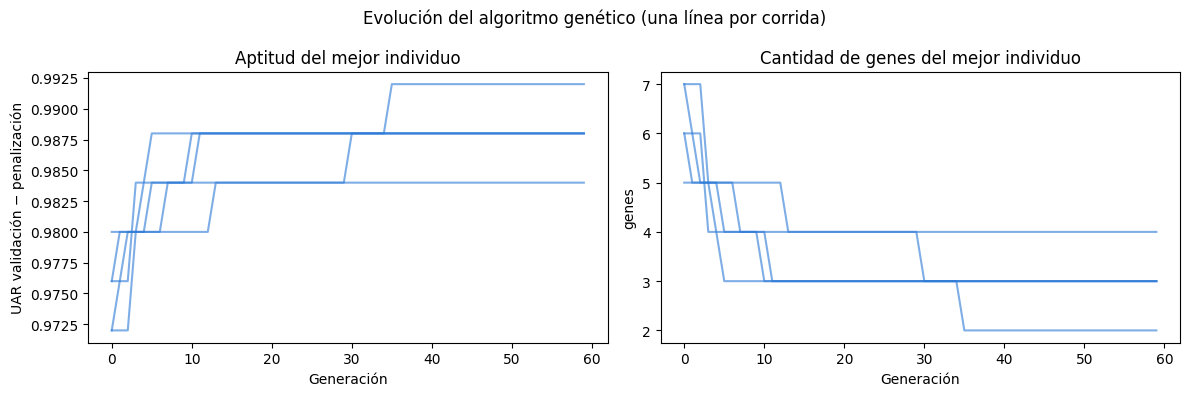

In [18]:
#cómo evoluciona el mejor individuo de cada corrida
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for ag in geneticos:
    cantidades = []
    for genes in ag.mejores:
        cantidades.append(len(genes))
    ejes[0].plot(ag.mejores_aptitudes, color=AZUL, alpha=0.6)
    ejes[1].plot(cantidades, color=AZUL, alpha=0.6)

ejes[0].set_title("Aptitud del mejor individuo")
ejes[0].set_xlabel("Generación")
ejes[0].set_ylabel("UAR validación − penalización")
ejes[1].set_title("Cantidad de genes del mejor individuo")
ejes[1].set_xlabel("Generación")
ejes[1].set_ylabel("genes")
fig.suptitle("Evolución del algoritmo genético (una línea por corrida)")
plt.tight_layout()
plt.show()

### Conclusiones

- El AG pasa de 7129 genes a **2–4 genes** y mejora el UAR de test frente a usar todos (0.83 vs 0.76 en promedio).
- **Hay sobreajuste**: validación da 1.0 y test varía entre corridas (0.76–0.94). Con 38 pacientes hay muchas combinaciones chicas que separan train por casualidad.
- Los 10 mejores del ranking, sin AG, dan más UAR de test (0.93) con más genes: el AG gana en **tamaño** del subconjunto, no en desempeño.